# Detekce čerpacích cyklů a kontrola fungování čerpadla

Analýza souboru `Pressure.csv` dle zadání popsaném v README.adoc: definice cyklů, prahové hodnoty (A), hypotéza trendu tlaku během cyklu (B).

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
pd.options.display.float_format = "{:.4f}".format

df = pd.read_csv("Pressure.csv", parse_dates=["Date"]).sort_values("Date").set_index("Date")

display(Markdown("## Data Preview"))
display(df.head(10))

#display(Markdown("## Summary Statistics"))
#display(df.describe())

display(Markdown("## Missing Values"))
display(df.isna().sum().to_frame("missing_count"))

#display(Markdown("## Data Info"))
#df.info()

## Data Preview

,Int,Pressure,PumpState
Date,,,
2017-08-13 00:27:40.050,0,1.7308,NaN
2017-08-13 02:10:00.500,0,1.5434,NaN
2017-08-13 03:01:49.500,0,NaN,16.0000
2017-08-13 03:02:08.000,0,1.3728,NaN
2017-08-13 03:02:15.500,0,NaN,32.0000
2017-08-13 03:02:58.000,0,1.5434,NaN
2017-08-13 03:35:33.590,0,NaN,1.0000
2017-08-13 03:35:33.880,0,1368.3842,NaN
2017-08-13 03:35:34.170,0,9133.9434,NaN


## Missing Values

,missing_count
Int,0
Pressure,2814
PumpState,19150


## Stav čerpadla (`PumpState`)

V CSV je `PumpState` vyplněn jen při **změně** stavu, jinde je `NaN`. Níže jsou všechny hodnoty, které se v datech vyskytují, a kolikrát byly **zalogovány** (počet řádků s neprázdným `PumpState`).

In [2]:
pump_counts = (
    df["PumpState"]
    .value_counts(dropna=False)
    .rename_axis("PumpState")
    .to_frame("count")
)

pump_counts.sort_index()

,count
PumpState,
0.0000,31
1.0000,153
2.0000,189
16.0000,154
32.0000,185
NaN,19150


# Pumping Cycle Algoritmus
- Algoritmus definuje validní čerpací cykly na základě změn hodnoty `PumpState`
- Cyklus začíná 10s po zalogování změny stavu na hodnotu `(1)`
- Cyklus končí 5s před zalogování změny stavu na hodnotu `(2)`
- Během cyklu `PumpState` zůstává na hodnotě `(1)` a nesmí se změnit na hodnotu jinou.
- V rámci cyklu se mohou vyskytovat další logy hodnoty `(1)`

## Edge cases
- Výskyt jiného stavu než `(1)` mezi `(1)` a `(2)` zneplatní cyklus
- Pokud nenásleduje stav `(2)`, cyklus není validní
- Po aplikaci posunů `+10s` a `-5s` může vzniknout prázdný interval
- Interval nemusí obsahovat žádné měření `Pressure` kvůli chybějícím nebo řídkým datům

In [3]:
# Cycle Detection Function
import numpy as np
from scipy import stats

# Strict numeric checks: PumpState in the assignment is numeric (1=pumping,2=pumped)
def _is_state_pumping(v):
    try:
        return int(v) == 1
    except (ValueError, TypeError):
        return False

def _is_state_pumped(v):
    try:
        return int(v) == 2
    except (ValueError, TypeError):
        return False


def detect_cycles(df, pressure_col='Pressure', state_col='PumpState',
                  start_offset=pd.Timedelta('10s'), end_offset=pd.Timedelta('5s')):
    """Detect pumping cycles following the README specification:
    - cycle starts `start_offset` after a logged PumpState == 1
    - cycle ends `end_offset` before a logged PumpState == 2
    - cycle is valid only if forward-filled PumpState remains as 1 for whole interval
    """
    df2 = df.copy()
    # forward-fill the pump state so each timestamp has the current state
    df2['_pump_ff'] = df[state_col].ffill()

    # events are rows where PumpState was explicitly logged
    events = df[state_col].dropna()
    starts = (events[events.apply(_is_state_pumping)].index + start_offset).tolist()
    ends = (events[events.apply(_is_state_pumped)].index - end_offset).tolist()

    starts.sort()
    ends.sort()

    cycles = []
    # index for ends
    ei = 0 
    for s in starts:
        # find first end after start
        while ei < len(ends) and ends[ei] <= s:
            ei += 1
        if ei >= len(ends):
            print(f"Warning: no more cycle ends after start at {s}, stopping detection")
            break
        e = ends[ei]
        # check that forward-filled PumpState is consistently 1 in [s,e]
        seg_state = df2['_pump_ff'].loc[s:e]
        if seg_state.empty:
            print(f"Warning: no data points between {s} and {e}, skipping cycle")
            continue
        if not seg_state.apply(_is_state_pumping).all():
            print(f"Warning: PumpState is not consistently 1 between {s} and {e}, skipping cycle")
            continue
        seg = df.loc[s:e]
        dur = e - s
        # compute trend if enough points
        slope = np.nan
        if len(seg) >= 2:
            x = (seg.index.view('int64') - seg.index.view('int64')[0]) / 1e9
            y = seg[pressure_col].values
            slope, intercept, r, p, se = stats.linregress(x, y)[:5]
        cycles.append({
            'start': s,
            'end': e,
            'duration_seconds': dur.total_seconds(),
            'n_points': len(seg),
            'pressure_min (cycle threshold)': seg[pressure_col].min() if len(seg) else np.nan,
            'pressure_max': seg[pressure_col].max() if len(seg) else np.nan,
            'pressure_mean': seg[pressure_col].mean() if len(seg) else np.nan,
            'trend_slope': slope,
        })
        ei += 1

    return pd.DataFrame(cycles)

# Run detection
cycles = detect_cycles(df)



# A) Prahové Hodnoty Cyklů

In [4]:
# Display results
display(Markdown('## Detekované cykly'))
display(cycles)

## Detekované cykly

,start,end,duration_seconds,n_points,pressure_min (cycle threshold),pressure_max,pressure_mean,trend_slope
0,2017-08-13 03:35:43.590,2017-08-13 03:37:13.630,90.0400,85,8.2568,7000.5081,491.0286,-24.4300
1,2017-08-13 07:09:15.170,2017-08-13 07:10:55.160,99.9900,84,7.9050,7000.5081,385.1872,-16.7667
2,2017-08-13 07:39:33.300,2017-08-13 07:40:30.280,56.9800,84,8.9999,6051.5248,399.1156,-35.0280
3,2017-08-13 11:14:40.130,2017-08-13 11:16:03.140,83.0100,85,8.6216,6051.5248,418.4055,-22.1712
4,2017-08-13 12:00:16.420,2017-08-13 12:01:01.450,45.0300,82,9.2596,7265.5804,502.2524,-53.7665
...,...,...,...,...,...,...,...,...
148,2017-09-11 00:01:49.110,2017-09-11 00:03:06.090,76.9800,82,9.7980,7000.5081,482.0164,-30.7068
149,2017-09-11 03:19:41.220,2017-09-11 03:20:51.200,69.9800,77,9.5256,6273.0914,462.7924,-29.2089
150,2017-09-11 10:26:09.410,2017-09-11 10:27:52.450,103.0400,86,9.1290,6273.0914,418.5258,-19.0362
151,2017-09-11 19:21:36.160,2017-09-11 19:23:23.160,107.0000,84,9.1290,7832.9396,534.3607,-24.1516


In [5]:
# Compute and display mean of cycle thresholds
mean_cycle_threshold = cycles['pressure_min (cycle threshold)'].mean()
display(Markdown(f"**Průměrná hodnota pressure_min (cycle threshold):** {mean_cycle_threshold:.4f}"))

**Průměrná hodnota pressure_min (cycle threshold):** 9.0608

### Outlier Report
- Při standardním Tukeyově pravidle (`k = 1.5`) se v datech nevyskytly žádné označené cykly
- Zatímco `k = 1.0` identifikovalo pět podezřelých cyklů, které při vizuální kontrole vyžadují bližší pozornost
- Pro každý nalezený cyklus je vygenerovaný interaktivní graf ve složce `html`

Flagged cycles: **5** / **153**

,start,end,duration_seconds,pressure_min (cycle threshold),trend_slope,outlier_pressure_min,outlier_duration,outlier_trend
5,2017-08-14 06:59:37.310,2017-08-14 07:01:40.280,122.9700,7.3464,-12.1944,True,False,False
15,2017-08-19 08:43:18.950,2017-08-19 08:45:23.000,124.0500,7.3464,-13.2983,True,False,False
9,2017-08-15 06:50:19.410,2017-08-15 06:52:17.410,118.0000,7.4554,-14.5464,True,False,False
63,2017-08-29 20:04:02.130,2017-08-29 20:06:01.090,118.9600,7.4554,-14.2686,True,False,False
147,2017-09-10 19:55:12.550,2017-09-10 19:57:42.550,150.0000,8.1381,-10.0366,False,True,False


### Vygenerované interaktivní HTML soubory

- valid: **148** files in `html/valid`

- suspect: **5** files in `html/suspect`

5

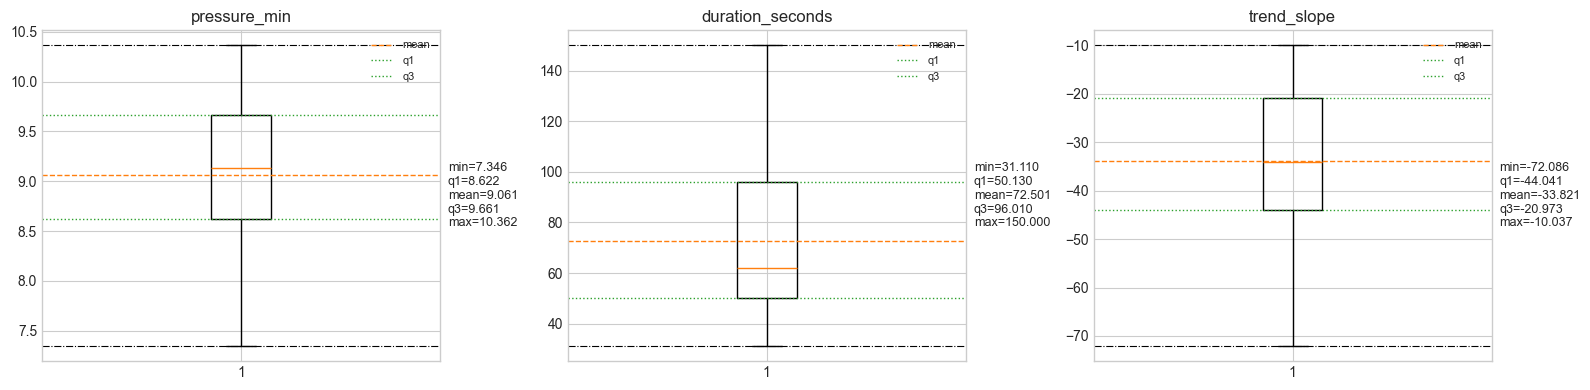

In [6]:
# Outlier detection for cycles
from scipy.stats import zscore
import os

# IQR-based flags for pressure_min and duration
def flag_outliers_iqr(series, k=1.0):
    s = series.dropna()
    if s.empty:
        return pd.Series(False, index=series.index)
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (series < lower) | (series > upper)

cycles['outlier_pressure_min'] = flag_outliers_iqr(cycles['pressure_min (cycle threshold)'])
cycles['outlier_duration'] = flag_outliers_iqr(cycles['duration_seconds'])

# Use z-score for trend slope (handles symmetric deviations)
if 'trend_slope' in cycles.columns and cycles['trend_slope'].notna().any():
    ts = cycles['trend_slope'].fillna(0)
    cycles['outlier_trend'] = np.abs(zscore(ts)) > 3
else:
    cycles['outlier_trend'] = False

# Combined flag
cycles['outlier_any'] = cycles[['outlier_pressure_min', 'outlier_duration', 'outlier_trend']].any(axis=1)

# Summary display
count_flagged = int(cycles['outlier_any'].sum())
display(Markdown(f"Flagged cycles: **{count_flagged}** / **{len(cycles)}**"))

# Show flagged cycles (compact)
disp_cols = ['start','end','duration_seconds','pressure_min (cycle threshold)','trend_slope','outlier_pressure_min','outlier_duration','outlier_trend']
display(cycles.loc[cycles['outlier_any'], disp_cols].sort_values('pressure_min (cycle threshold)'))

# Quick diagnostic plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Pressure min boxplot
axes[0].boxplot(cycles['pressure_min (cycle threshold)'].dropna())
axes[0].set_title('pressure_min')

# Duration boxplot
axes[1].boxplot(cycles['duration_seconds'].dropna())
axes[1].set_title('duration_seconds')

# Trend slope boxplot
if 'trend_slope' in cycles.columns:
    axes[2].boxplot(cycles['trend_slope'].dropna())
else:
    axes[2].text(0.5, 0.5, 'no trend_slope', ha='center')
axes[2].set_title('trend_slope')

# Annotate each plot with min, q1, mean, q3, max and draw lines
metrics = [
    ('pressure_min (cycle threshold)', axes[0]),
    ('duration_seconds', axes[1]),
    ('trend_slope', axes[2])
]
for name, ax in metrics:
    if name not in cycles.columns:
        continue
    s = cycles[name].dropna()
    if s.empty:
        continue
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    mean = s.mean()
    mn = s.min()
    mx = s.max()
    # horizontal lines for values (if within axis range)
    ax.axhline(mean, color='C1', linestyle='--', linewidth=1, label='mean')
    ax.axhline(q1, color='C2', linestyle=':', linewidth=1, label='q1')
    ax.axhline(q3, color='C2', linestyle=':', linewidth=1, label='q3')
    ax.axhline(mn, color='k', linestyle='-.', linewidth=0.8, label='min')
    ax.axhline(mx, color='k', linestyle='-.', linewidth=0.8, label='max')
    stats_text = f"min={mn:.3f}\nq1={q1:.3f}\nmean={mean:.3f}\nq3={q3:.3f}\nmax={mx:.3f}"
    ax.text(1.02, 0.5, stats_text, transform=ax.transAxes, fontsize=9, verticalalignment='center')
    # avoid duplicate legends
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles[:3], labels[:3], loc='upper right', fontsize=8)

plt.tight_layout()

# Generate interactive HTML for every cycle, split into valid/suspect directories
try:
    import plotly.express as px
    import plotly.io as pio
    pio.renderers.default = 'iframe_connected'

    base_dir = 'html'
    valid_dir = os.path.join(base_dir, 'valid')
    suspect_dir = os.path.join(base_dir, 'suspect')
    os.makedirs(valid_dir, exist_ok=True)
    os.makedirs(suspect_dir, exist_ok=True)

    html_valid = []
    html_suspect = []

    for idx, row in cycles.iterrows():
        s, e = row['start'], row['end']
        seg = df.loc[s:e]
        if seg.empty:
            continue
        fig = px.line(seg.reset_index(), x='Date', y='Pressure', title=f'Cycle {idx} ({s} → {e})', hover_data={'Pressure':':.4f'})
        thr = row.get('pressure_min (cycle threshold)')
        meanv = row.get('pressure_mean')
        if pd.notna(thr):
            fig.add_hline(y=thr, line_dash='dash', line_color='red', annotation_text='threshold', annotation_position='top left')
        if pd.notna(meanv):
            fig.add_hline(y=meanv, line_dash='dot', line_color='orange', annotation_text='mean', annotation_position='bottom left')
        target_dir = suspect_dir if bool(row.get('outlier_any', False)) else valid_dir
        fname = f'cycle_{idx}.html'
        out_path = os.path.join(target_dir, fname)
        pio.write_html(fig, out_path, full_html=True)
        if target_dir is suspect_dir:
            html_suspect.append(out_path)
        else:
            html_valid.append(out_path)

    display(Markdown('### Vygenerované interaktivní HTML soubory'))
    display(Markdown(f'- valid: **{len(html_valid)}** files in `{valid_dir}`'))
    display(Markdown(f'- suspect: **{len(html_suspect)}** files in `{suspect_dir}`'))
except Exception as e:
    display(Markdown(f'Plotly se nepodařilo použít: {e}'))

# Return small summary
count_flagged

In [7]:
# Interactive boxplots with data points visible (Plotly)
import os
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'iframe_connected'

# use cycles DataFrame prepared earlier
dfc = cycles.reset_index(drop=True)
cols = ['pressure_min (cycle threshold)', 'duration_seconds', 'trend_slope']
fig = make_subplots(rows=3, cols=1, shared_xaxes=False, subplot_titles=('Pressure min (cycle threshold)', 'Duration (s)', 'Trend slope'))
for i, col in enumerate(cols, start=1):
    if col not in dfc.columns:
        continue
    # box with all points shown and slight jitter
    fig.add_trace(go.Box(y=dfc[col], name=col, boxpoints='all', jitter=0.6, pointpos=0, marker=dict(size=6)), row=i, col=1)

fig.update_layout(height=900, title_text='Interactive boxplots with points')

# ensure html dir and write
os.makedirs('html', exist_ok=True)
out_html = os.path.join('html', 'outliers_boxplots_interactive.html')
pio.write_html(fig, out_html, full_html=True)
display(Markdown(f'### Interactive boxplots saved to `{out_html}`'))
fig

### Interactive boxplots saved to `html/outliers_boxplots_interactive.html`

## Korelace mezi minimálním tlakem cyklu a délkou cyklu

In [8]:
# Korelace mezi minimálním tlakem cyklu a délkou cyklu
import numpy as np
import plotly.express as px
from IPython.display import Markdown, display

corr_df = cycles[['pressure_min (cycle threshold)', 'duration_seconds']].dropna().copy()

if corr_df.empty:
    print("Korelační analýza není dostupná: chybí kompletní páry hodnot.")
else:
    fig_rel = px.scatter(
        corr_df,
        x='pressure_min (cycle threshold)',
        y='duration_seconds',
        trendline='ols',
        title='Vztah minimálního tlaku cyklu a délky cyklu',
        labels={
            'pressure_min (cycle threshold)': 'Minimální tlak v cyklu',
            'duration_seconds': 'Délka cyklu (sekundy)'
        }
    )
    fig_rel.update_layout(height=520)
    fig_rel.show()

Byla zjištěna silná negativní korelace mezi minimálním tlakem v cyklu a délkou cyklu. Tento vztah je dán tím, že tlak během cyklu kontinuálně klesá - delší cykly tak umožňují dosažení nižších tlakových hodnot.

- Pearsonova korelace: **-0.664**  
- Spearmanova korelace: **-0.549**  
- Interpretace: **silná negativní závislost**

## Testování nulové hypotézy, že prahové hodnoty cyklů jsou v čase neměnné.
- **H0:** Prahové hodnoty cyklů jsou v čase invariantní (sklon = 0).
- **H1:** Prahové hodnoty cyklů se v čase mění (sklon != 0).

In [9]:
# Finally, test the null hypothesis that cycle thresholds are invariant over time.
# H0: cycle thresholds are invariant over time (slope = 0)
# H1: cycle thresholds change over time (slope != 0)

from scipy import stats
import plotly.express as px
from IPython.display import Markdown, display

alpha = 0.05
hyp_df = cycles[['start', 'pressure_min (cycle threshold)']].dropna().copy()

if hyp_df.empty or len(hyp_df) < 3:
    display(Markdown('### Test nulové hypotézy není dostupný: nedostatek dat.'))
else:
    hyp_df['start'] = pd.to_datetime(hyp_df['start'])
    t_sec = (hyp_df['start'] - hyp_df['start'].min()).dt.total_seconds()
    y = hyp_df['pressure_min (cycle threshold)']

    lr = stats.linregress(t_sec, y)
    decision = 'Zamítáme H0' if lr.pvalue < alpha else 'Nezamítáme H0'

    display(Markdown(
        f'- Odhad sklonu: **{lr.slope:.6e}** (jednotek tlaku / sekunda)  \n'
        f'- p-hodnota: **{lr.pvalue:.4g}**  \n'
        f'- Pearsonovo R: **{lr.rvalue:.3f}**  \n'
        f'- Rozhodnutí pro alpha = {alpha}: **{decision}**'
    ))

    fig_h0 = px.scatter(
        hyp_df,
        x='start',
        y='pressure_min (cycle threshold)',
        trendline='ols',
        title='Prahové hodnoty cyklů v čase (test H0 o invarianci)',
        labels={
            'start': 'Čas začátku cyklu',
            'pressure_min (cycle threshold)': 'Minimální tlak v cyklu'
        }
    )
    fig_h0.update_layout(height=520)
    fig_h0.show()

- Odhad sklonu: **2.868323e-07** (jednotek tlaku / sekunda)  
- p-hodnota: **0.0003055**  
- Pearsonovo R: **0.288**  
- Rozhodnutí pro alpha = 0.05: **Zamítáme H0**

# B) Hypotéza o trendu cyklu indikujícím stav čerpadla
- **Kde jsou grafy z úkolu A (průběh tlaku v čase uvnitř cyklu):** po spuštění příslušné buňky v části A se ukládají jako HTML (relativně k pracovnímu adresáři notebooku, obvykle kořen repozitáře):
  - `html/valid/cycle_<index>.html` — cykly bez kombinovaného outlier příznaku,
  - `html/suspect/cycle_<index>.html` — cykly označené jako podezřelé (`outlier_any`).
  Doplňkový souhrnný pohled na metriky cyklů (ne časový průběh tlaku uvnitř cyklu) je v `html/outliers_boxplots_interactive.html`. Statické matplotlib boxploty zůstávají jen ve výstupu příslušných buněk notebooku.

- Vizuální kontrola těchto grafů (zejména souborů v `html/valid/` a `html/suspect/`) u více čerpacích cyklů ukazuje, že tlak v průběhu každého cyklu obecně v čase klesá. V analyzovaných cyklech je často patrná krátkodobá lokální fluktuace („hrb“), kdy tlak dočasně vzroste, než opět pokračuje v poklesu. Přesto celkový trend zůstává zřetelně klesající.

- Data jsou tedy **vizuálně** v souladu s hypotézou, že zdravé čerpadlo vykazuje během čerpacího cyklu postupný pokles tlaku (u jednotlivých cyklů lze ověřit i sloupcem `trend_slope` v tabulce `cycles`).


In [10]:
# Ukázka: průběh tlaku v cyklech 10, 20 a 30 (stejná logika jako export HTML v části A)
from IPython.display import display, Markdown
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

pio.renderers.default = "iframe_connected"

EXAMPLE_IDS = [10, 20, 30]
titles = []
for cid in EXAMPLE_IDS:
    if cid >= len(cycles):
        titles.append(f"Cyklus {cid} — mimo rozsah (jen {len(cycles)} cyklů)")
        continue
    row = cycles.iloc[cid]
    susp = bool(row.get("outlier_any", False)) if "outlier_any" in cycles.columns else False
    tag = " [suspect]" if susp else ""
    titles.append(f"Cyklus {cid}{tag}")

fig = make_subplots(rows=3, cols=1, subplot_titles=titles, vertical_spacing=0.08)

for r, cid in enumerate(EXAMPLE_IDS, start=1):
    if cid >= len(cycles):
        continue
    row = cycles.iloc[cid]
    s, e = row["start"], row["end"]
    seg = df.loc[s:e]
    if seg.empty:
        display(Markdown(f"**Cyklus {cid}:** v intervalu nejsou žádné body tlaku."))
        continue
    t = seg.reset_index()["Date"]
    fig.add_trace(
        go.Scatter(
            x=t,
            y=seg["Pressure"],
            mode="lines",
            name=f"cyklus {cid}",
            showlegend=False,
            hovertemplate="%{x}<br>Pressure: %{y:.4f}<extra></extra>",
        ),
        row=r,
        col=1,
    )
    thr = row.get("pressure_min (cycle threshold)")
    meanv = row.get("pressure_mean")
    if pd.notna(thr):
        fig.add_hline(
            y=float(thr),
            line_dash="dash",
            line_color="red",
            annotation_text="práh cyklu",
            annotation_position="top left",
            row=r,
            col=1,
        )
    if pd.notna(meanv):
        fig.add_hline(
            y=float(meanv),
            line_dash="dot",
            line_color="orange",
            annotation_text="průměr",
            annotation_position="bottom left",
            row=r,
            col=1,
        )

fig.update_layout(height=1000, title_text="Ukázka průběhu tlaku uvnitř cyklu (B)", hovermode="x unified")
fig.update_yaxes(title_text="Pressure")
fig.update_xaxes(title_text="Date", row=3, col=1)
fig.show()

links = []
for cid in EXAMPLE_IDS:
    if cid >= len(cycles):
        continue
    row = cycles.iloc[cid]
    sub = "suspect" if row.get("outlier_any", False) else "valid"
    links.append(f"`html/{sub}/cycle_{cid}.html`")
if links:
    display(Markdown("**Odpovídající soubory z úkolu A:** " + ", ".join(links)))


**Odpovídající soubory z úkolu A:** `html/valid/cycle_10.html`, `html/valid/cycle_20.html`, `html/valid/cycle_30.html`